# Fast Food Marketing Campaign A/B Test

## Project Overview
analyzes the effectiveness of three different marketing campaigns for a new fast-food menu item. The objective is to determine which promotion leads to the highest sales, using A/B testing results from multiple store locations over four weeks.

## Columns
- **MarketID**: unique identifier for market
- **MarketSize**: size of market area by sales
- **LocationID**: unique identifier for store location
- **AgeOfStore**: age of store in years
- **Promotion**: one of three promotions that were tested
- **week**: one of four weeks when the promotions were run
- **SalesInThousands**: sales amount for a specific LocationID, Promotion, and week

---

In [4]:
# Setup: Imports and Configuration
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Paths
DATA_PATH = Path('./Project-1/WA_Marketing-Campaign.csv')
print(DATA_PATH.resolve())
print(DATA_PATH.exists())

C:\Users\xxslo\OneDrive\Desktop\AAI-bootcamp\student\C2\M4\Project-1\WA_Marketing-Campaign.csv
True


## Data Loading & Quick Validation

Load the dataset and perform initial validation checks: shape, columns, data types, and a sample of the data.

In [5]:
# Load data and validate
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.info()
df.head()

Shape: (548, 7)
Columns: ['MarketID', 'MarketSize', 'LocationID', 'AgeOfStore', 'Promotion', 'week', 'SalesInThousands']
<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Data Cleaning and Preparation

Drop unnecessary columns and check a sample of the cleaned data.

In [6]:
# Drop columns not needed for analysis
df = df.drop(columns=['MarketID','MarketSize','LocationID','AgeOfStore','week'])
df.sample(5)

,Promotion,SalesInThousands
247,1,58.04
78,3,79.36
245,1,62.63
353,1,43.11
477,3,51.17


## Exploratory Data Analysis (EDA)

Calculate and visualize the average sales for each promotion.

In [7]:
# Calculate average sales for each promotion
avg_sales = df.groupby('Promotion')['SalesInThousands'].mean().reset_index()
avg_sales = avg_sales.rename(columns={'SalesInThousands': 'SalesInThousandsAvg'})
avg_sales

,Promotion,SalesInThousandsAvg
0,1,58.099012
1,2,47.329415
2,3,55.364468


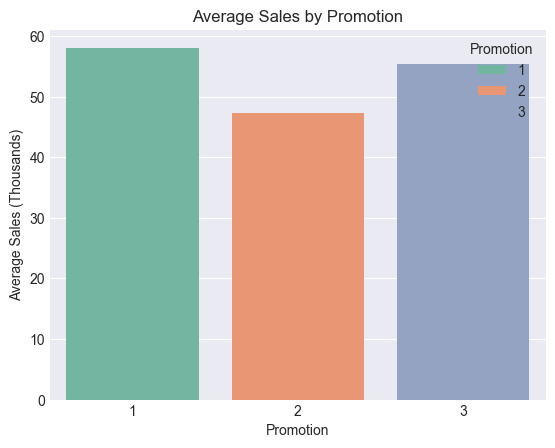

In [13]:
# Plotting the average sales for each promotion
sns.barplot(x='Promotion', y='SalesInThousandsAvg', data=avg_sales, hue='Promotion', palette='Set2')
plt.title('Average Sales by Promotion')
plt.xlabel('Promotion')
plt.ylabel('Average Sales (Thousands)')
plt.show()

C:\Users\xxslo\AppData\Local\Temp\ipykernel_21840\2027514340.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x='Promotion', y='SalesInThousands', data=df, kind='box', palette='Set2')


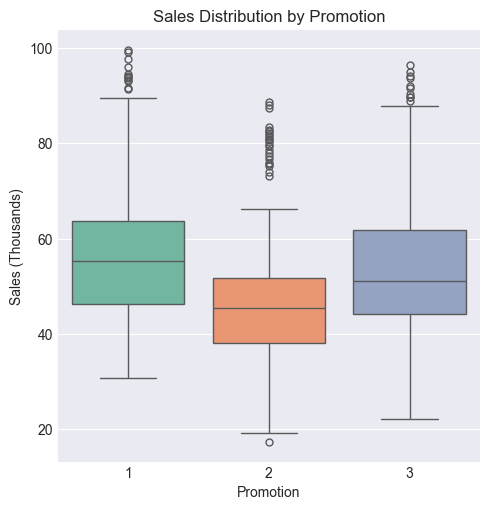

In [ ]:
# Boxplot to show sales distribution for each promotion
sns.catplot(x='Promotion', y='SalesInThousands', data=df, kind='box', palette='Set2')
plt.title('Sales Distribution by Promotion')
plt.xlabel('Promotion')
plt.ylabel('Sales (Thousands)')
plt.show()

### Interpretation

The bar plot shows the average sales for each promotion, helping us compare their effectiveness. The boxplot below provides more detail, showing the distribution and spread of sales for each promotion, including outliers. This helps us see not only which promotion performed best on average, but also how consistent the results were for each campaign.

## Statistical Testing

To determine if the differences in sales between promotions are statistically significant, we use Tukey's HSD test.

In [9]:
# Tukey's HSD test for pairwise comparison
alpha = 0.05
tukey = pairwise_tukeyhsd(endog=df['SalesInThousands'], groups=df['Promotion'], alpha=alpha)
print(tukey)
print("significant!" if (tukey.reject.any()) else "not enough evidence")

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------
significant!


### Interpretation

The Tukey HSD test results above indicate whether the differences in average sales between promotions are statistically significant. If 'significant!' is printed, at least one pair of promotions has a significant difference in sales.

## Summary & Next Steps

- The analysis compared three marketing promotions for a new fast-food menu item.
- Average sales were calculated and visualized for each promotion.
- Statistical testing (Tukey HSD) was used to check for significant differences.
- The best-performing promotion can be identified based on the results above.

**Next Steps:**
- Investigate other factors (e.g., market size, store age) if needed.
- Consider running further experiments or collecting more data for robust conclusions.